# Bank Marketing Data-A Decision Tree Approach

# Objective:

The aim of this attempt is to predict the client will subscribe(yes/no) to a term deposite, by building a classification model using Decision Tree.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn import datasets
from io import StringIO
from sklearn.tree import export_graphviz
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics
%matplotlib inline

In [2]:
bank = pd.read_csv('bank.csv')
bank.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [4]:
bank.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [5]:
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


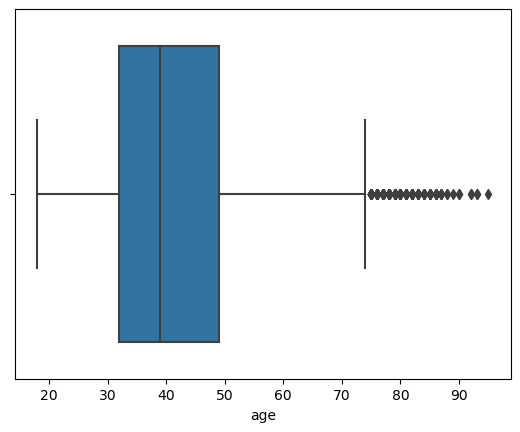

In [6]:
#boxplot for age

g = sns.boxplot(x=bank['age'])

C:\Users\khank\AppData\Local\Temp\ipykernel_8820\2916832678.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bank.age, bins=100)


<Axes: xlabel='age', ylabel='Density'>

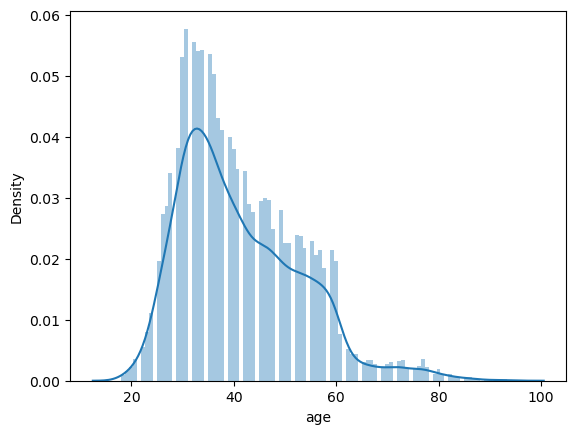

In [7]:
#Distribution of Age

sns.distplot(bank.age, bins=100)

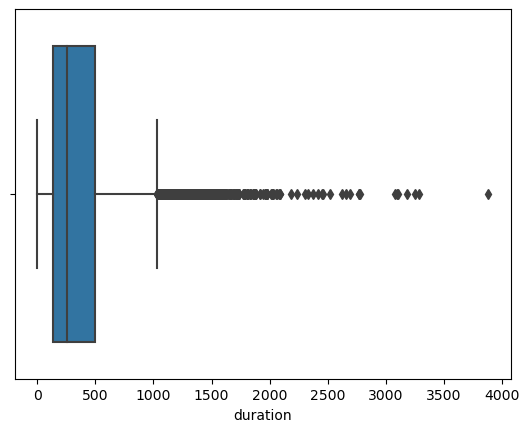

In [8]:
#Boxplot for duration

g = sns.boxplot(x=bank['duration'])

C:\Users\khank\AppData\Local\Temp\ipykernel_8820\1340432733.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(bank.duration, bins=100)


<Axes: xlabel='duration', ylabel='Density'>

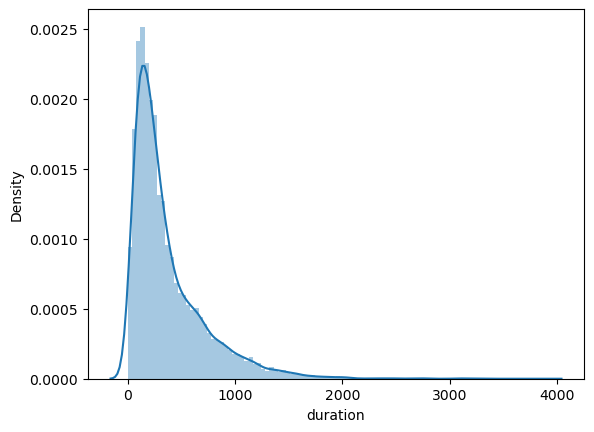

In [9]:
# Distplot for duration

sns.distplot(bank.duration, bins=100)

# Convert Categorical Data

In [10]:
# Make a copy for parsing

bank_data = bank.copy()

In [11]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [12]:
#Combine similiar jobs into Categories

bank_data['job'] = bank_data['job'].replace(['management','admin'],'white-collar')
bank_data['job'] = bank_data['job'].replace(['services','housemaid'],'pink-collar')
bank_data['job'] = bank_data['job'].replace(['retired','student','unemployed','unknown'],'other')



In [13]:
bank_data.job.value_counts()

white-collar     2566
blue-collar      1944
technician       1823
other            1565
admin.           1334
pink-collar      1197
self-employed     405
entrepreneur      328
Name: job, dtype: int64

In [14]:
bank_data.poutcome.value_counts()

unknown    8326
failure    1228
success    1071
other       537
Name: poutcome, dtype: int64

In [15]:
# Combine 'unknown' and 'other' as 'other' isn't really match with either 'success' or 'failure'
bank_data['poutcome'] = bank_data['poutcome'].replace(['other'], 'unknown')



In [16]:
bank_data.poutcome.value_counts()

unknown    8863
failure    1228
success    1071
Name: poutcome, dtype: int64

In [17]:
bank_data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [18]:
#Drop contact as every participant has been contacted.

bank_data.drop('contact', axis=1, inplace=True)

In [19]:
#Altering the values of 'Default' from 'yes/no' to "1\0"

bank_data['default']

bank_data['default_cat'] = bank_data['default'].map({'yes':1, 'no':0})
bank_data.drop('default',axis=1, inplace=True)

In [20]:
#Altering the values for housing

bank_data['housing']

bank_data['housing_cat'] = bank_data['housing'].map({'yes':1, 'no':0})

bank_data.drop('housing', axis=1, inplace=True)

In [21]:
#Altering the values for loan

bank_data['loan_cat'] = bank_data['loan'].map({'yes':1, "no":0})
bank_data.drop('loan',axis=1, inplace = True)

In [22]:
#Drop month (of the year) and day( of the month) which dont have any special meaning

bank_data.drop('month', axis=1, inplace=True)
bank_data.drop('day',axis=1,inplace=True)

In [23]:
#Altering the values for deposite

bank_data['deposite_cat'] = bank_data['deposit'].map({'yes':1, 'no':0})

bank_data.drop('deposit', axis=1, inplace=True)

In [24]:
# pdays: number of days that passed by after the client was last contacted from a previous campaign
#-1 means client was not previously contacted

print("Customers that have not been contacted before :", len(bank_data[bank_data.pdays==-1]))
print('Maximum values on pdays  :', bank_data['pdays'].max())

Customers that have not been contacted before : 8324
Maximum values on pdays  : 854


In [25]:
# Map padys=-1 into a large value (10000 is used) to indicate that it is so

bank_data.loc[bank_data['pdays']== -1, 'pdays'] = 1000

In [26]:
# Create a new column: recent_pdays 
bank_data['recent_pdays'] = np.where(bank_data['pdays'], 1/bank_data.pdays, 1/bank_data.pdays)

# Drop 'pdays'
bank_data.drop('pdays', axis=1, inplace = True)


In [27]:
bank_data.tail()

,age,job,marital,education,balance,duration,campaign,previous,poutcome,default_cat,housing_cat,loan_cat,deposite_cat,recent_pdays
11157,33,blue-collar,single,primary,1,257,1,0,unknown,0,1,0,0,0.001000
11158,39,pink-collar,married,secondary,733,83,4,0,unknown,0,0,0,0,0.001000
11159,32,technician,single,secondary,29,156,2,0,unknown,0,0,0,0,0.001000
11160,43,technician,married,secondary,0,9,2,5,failure,0,0,1,0,0.005814
11161,34,technician,married,secondary,0,628,1,0,unknown,0,0,0,0,0.001000


# Convert  to dummy values

In [28]:
bank_with_dummies = pd.get_dummies(data=bank_data, columns=['job','marital','education','poutcome'],
                                  prefix=['job','marital','education','poutcome'])

bank_with_dummies.head(5)

,age,balance,duration,campaign,previous,default_cat,housing_cat,loan_cat,deposite_cat,recent_pdays,...,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_success,poutcome_unknown
0,59,2343,1042,1,0,0,1,0,1,0.001,...,0,1,0,0,1,0,0,0,0,1
1,56,45,1467,1,0,0,0,0,1,0.001,...,0,1,0,0,1,0,0,0,0,1
2,41,1270,1389,1,0,0,1,0,1,0.001,...,0,1,0,0,1,0,0,0,0,1
3,55,2476,579,1,0,0,1,0,1,0.001,...,0,1,0,0,1,0,0,0,0,1
4,54,184,673,2,0,0,0,0,1,0.001,...,0,1,0,0,0,1,0,0,0,1


In [30]:
bank_with_dummies.shape

(11162, 28)

In [31]:
bank_with_dummies.describe()

,age,balance,duration,campaign,previous,default_cat,housing_cat,loan_cat,deposite_cat,recent_pdays,...,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_success,poutcome_unknown
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,...,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,371.993818,2.508421,0.832557,0.015051,0.473123,0.130801,0.473840,0.003795,...,0.115839,0.568984,0.315176,0.134385,0.490593,0.330496,0.044526,0.110016,0.095951,0.794033
std,11.913369,3225.413326,347.128386,2.722077,2.292007,0.121761,0.499299,0.337198,0.499338,0.030623,...,0.320047,0.495241,0.464607,0.341080,0.499934,0.470413,0.206270,0.312924,0.294537,0.404424
min,18.000000,-6847.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,122.000000,138.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,39.000000,550.000000,255.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,49.000000,1708.000000,496.000000,3.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.001919,...,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,95.000000,81204.000000,3881.000000,63.000000,58.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Observation on whole population

<Axes: xlabel='age', ylabel='balance'>

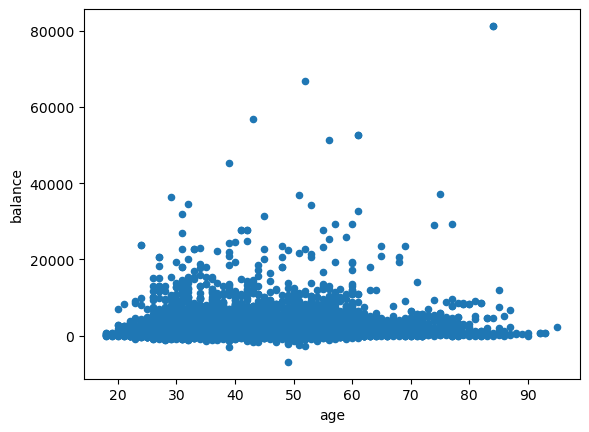

In [33]:
#using scactterplot showing age and balance
bank_with_dummies.plot(kind='scatter', x='age', y='balance')

# Across all ages, majority of people have savings of less than 20000.


<Axes: ylabel='Frequency'>

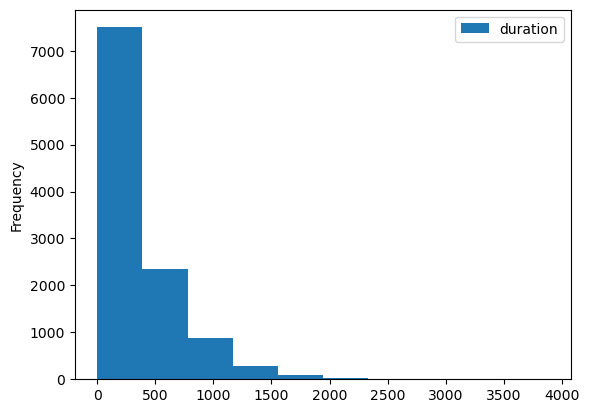

In [35]:
bank_with_dummies.plot(kind='hist',x='poutcome_success', y='duration')

Analysis on people who sign up for a term deposite

In [36]:
bank_with_dummies[bank_data.deposite_cat ==1].describe()

,age,balance,duration,campaign,previous,default_cat,housing_cat,loan_cat,deposite_cat,recent_pdays,...,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_success,poutcome_unknown
count,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.0,5289.000000,...,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000,5289.000000
mean,41.670070,1804.267915,537.294574,2.141047,1.170354,0.009832,0.365854,0.091511,1.0,0.004814,...,0.117603,0.520892,0.361505,0.111741,0.463226,0.377387,0.047646,0.116846,0.184912,0.698242
std,13.497781,3501.104777,392.525262,1.921826,2.553272,0.098676,0.481714,0.288361,0.0,0.035622,...,0.322167,0.499611,0.480482,0.315078,0.498693,0.484779,0.213036,0.321267,0.388263,0.459064
min,18.000000,-3058.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.001000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,210.000000,244.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.001000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,38.000000,733.000000,426.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.001000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,50.000000,2159.000000,725.000000,3.000000,1.000000,0.000000,1.000000,0.000000,1.0,0.005128,...,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,95.000000,81204.000000,3881.000000,32.000000,58.000000,1.000000,1.000000,1.000000,1.0,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [37]:
# People signed up to a term deposite having a personal loan (loan_cat) and housing loan (housing_cat)

len(bank_with_dummies[(bank_with_dummies.deposite_cat ==1) & (bank_with_dummies.loan_cat) &(bank_with_dummies.housing_cat)])

265

In [38]:
# People signed up to a term deposite with a credit default 
len(bank_with_dummies[(bank_with_dummies.deposite_cat ==1 )& (bank_with_dummies.default_cat ==1)])

52

<Axes: xlabel='job', ylabel='deposite_cat'>

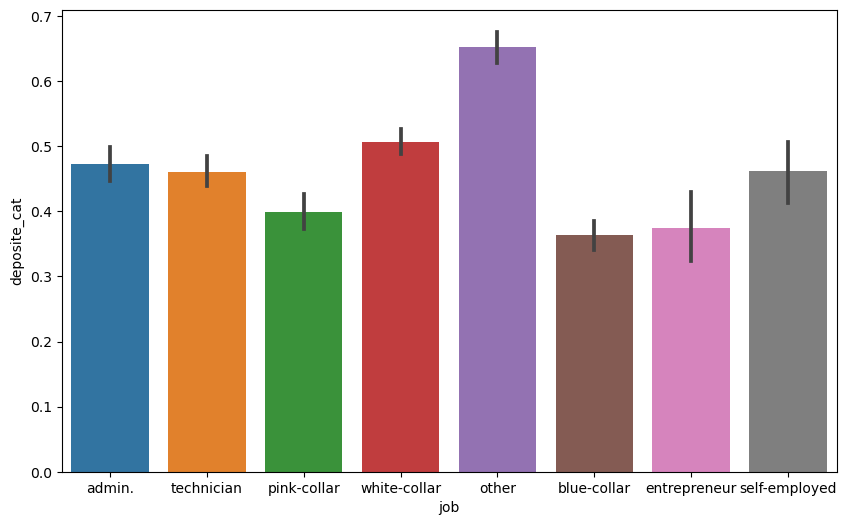

In [39]:
#bar chart of job vs deposite
plt.figure(figsize = (10,6))
sns.barplot(x='job', y='deposite_cat', data = bank_data)

<Axes: xlabel='poutcome', ylabel='duration'>

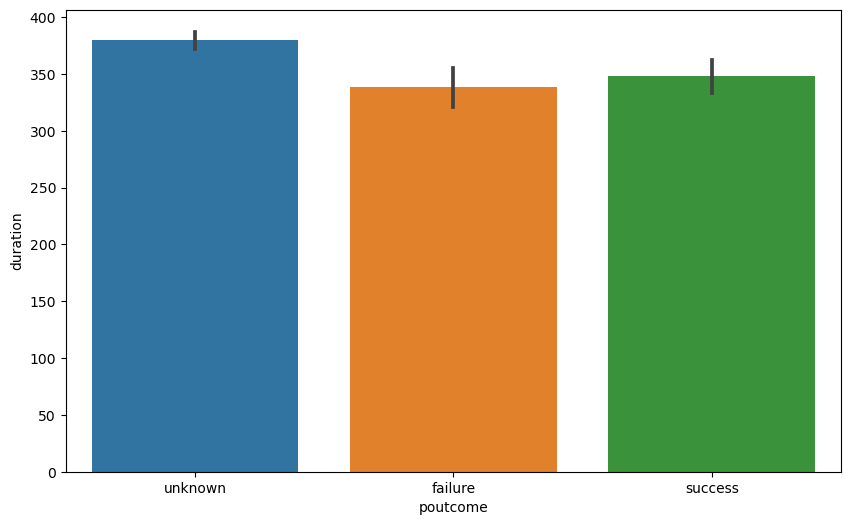

In [40]:
#ar chart of 'previous outcome' vs 'call duration'

plt.figure(figsize = (10,6))
sns.barplot(x='poutcome', y='duration',data = bank_data)

# Classification


In [59]:
bankcl = bank_with_dummies

In [60]:
corr = bankcl.corr()
corr

,age,balance,duration,campaign,previous,default_cat,housing_cat,loan_cat,deposite_cat,recent_pdays,...,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,poutcome_failure,poutcome_success,poutcome_unknown
age,1.000000,0.112300,0.000189,-0.005278,0.020169,-0.011425,-0.168700,-0.031418,0.034901,0.018795,...,0.186349,0.318436,-0.467799,0.231150,-0.094400,-0.101372,0.077761,-0.008071,0.062114,-0.038992
balance,0.112300,1.000000,0.022436,-0.013894,0.030805,-0.060954,-0.077092,-0.084589,0.081129,-0.004978,...,-0.017586,0.025431,-0.014994,-0.000673,-0.070609,0.069128,0.014596,0.001695,0.045603,-0.034524
duration,0.000189,0.022436,1.000000,-0.041557,-0.026716,-0.009760,0.035051,-0.001914,0.451919,-0.014339,...,0.021364,-0.036179,0.023847,0.013405,0.003820,-0.006813,-0.015887,-0.033966,-0.022578,0.042725
campaign,-0.005278,-0.013894,-0.041557,1.000000,-0.049699,0.030975,0.006660,0.034722,-0.128081,-0.024669,...,-0.006828,0.047722,-0.046165,0.019915,-0.013834,-0.005427,0.012976,-0.080188,-0.091807,0.128907
previous,0.020169,0.030805,-0.026716,-0.049699,1.000000,-0.035273,-0.000840,-0.022668,0.139867,0.114368,...,-0.026566,-0.005176,0.023817,-0.024852,-0.004620,0.028146,-0.011898,0.335870,0.325477,-0.496921
default_cat,-0.011425,-0.060954,-0.009760,0.030975,-0.035273,1.000000,0.011076,0.076434,-0.040680,-0.010628,...,0.019633,-0.006819,-0.006255,0.013858,-0.000618,-0.011768,0.005421,-0.024650,-0.040272,0.048403
housing_cat,-0.168700,-0.077092,0.035051,0.006660,-0.000840,0.011076,1.000000,0.076761,-0.203888,-0.029101,...,0.007430,0.036305,-0.043817,0.017002,0.118514,-0.114955,-0.053191,0.087741,-0.136299,0.031375
loan_cat,-0.031418,-0.084589,-0.001914,0.034722,-0.022668,0.076434,0.076761,1.000000,-0.110580,-0.011964,...,0.026463,0.044148,-0.065288,0.006854,0.079583,-0.067513,-0.050249,0.006264,-0.080370,0.053686
deposite_cat,0.034901,0.081129,0.451919,-0.128081,0.139867,-0.040680,-0.203888,-0.110580,1.000000,0.031574,...,0.005228,-0.092157,0.094632,-0.063002,-0.051952,0.094598,0.014355,0.020714,0.286642,-0.224785
recent_pdays,0.018795,-0.004978,-0.014339,-0.024669,0.114368,-0.010628,-0.029101,-0.011964,0.031574,1.000000,...,-0.019844,0.009783,0.003242,-0.006266,-0.017005,0.016671,0.013559,0.043823,0.112707,-0.115991


Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

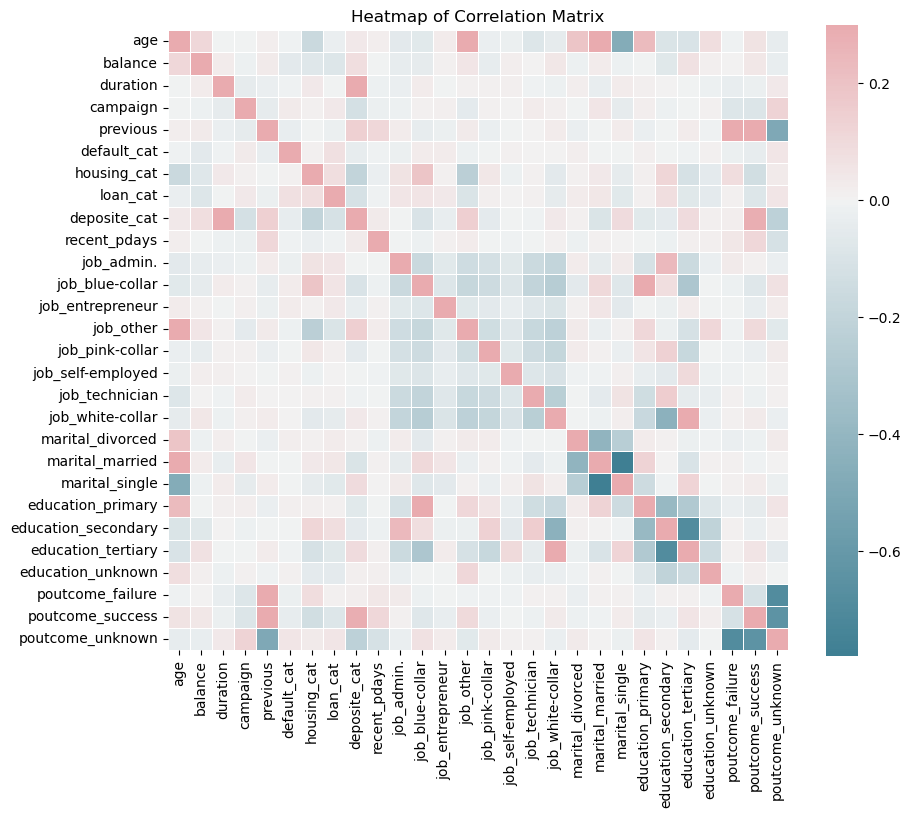

In [61]:
#heatmap

plt.figure(figsize=(10,10))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, cmap=cmap, vmax=.3, center=0, square=True, linewidth =.5, cbar_kws={'shrink': .82})
plt.title('Heatmap of Correlation Matrix')

In [67]:
# Extract the deposte_cat column (the dependent variable)
corr_deposite = pd.DataFrame(corr['deposite_cat'].drop('deposite_cat'))
corr_deposite.sort_values(by = 'deposite_cat', ascending = False)

,deposite_cat
duration,0.451919
poutcome_success,0.286642
job_other,0.144408
previous,0.139867
marital_single,0.094632
education_tertiary,0.094598
balance,0.081129
job_white-collar,0.036301
age,0.034901
recent_pdays,0.031574


# Building the Data model


In [68]:
bankcl.deposite_cat.value_counts()

0    5873
1    5289
Name: deposite_cat, dtype: int64

In [73]:
#Train-Test split: 20% test data

data_drop_deposite = bankcl.drop('deposite_cat', axis=1)
label = bankcl.deposite_cat
data_train, data_test, label_train, label_test = train_test_split(data_drop_deposite, label, test_size = 0.2, random_state = 50)

In [74]:
from sklearn import tree


In [75]:
#Decision Tree with depth = 2

dt2 = tree.DecisionTreeClassifier(random_state=1, max_depth=2)
dt2.fit(data_train, label_train)

dt2_score_train = dt2.score(data_train, label_train)
print("Training Score =  ", dt2_score_train)

dt2_score_test = dt2.score(data_test, label_test)
print('Testing Score = ', dt2_score_test)

Training Score =   0.7285250307985217
Testing Score =  0.7268248992386923


In [76]:
#Decision Tree with depth = 3

dt3 = tree.DecisionTreeClassifier(random_state=1, max_depth=3)
dt3.fit(data_train, label_train)

dt3_score_train = dt3.score(data_train, label_train)
print("Training Score =  ", dt3_score_train)

dt3_score_test = dt3.score(data_test, label_test)
print('Testing Score = ', dt3_score_test)

Training Score =   0.770411020271027
Testing Score =  0.7572772055530677


In [77]:
#Decision Tree with depth = 4

dt4 = tree.DecisionTreeClassifier(random_state=1, max_depth=4)
dt4.fit(data_train, label_train)

dt4_score_train = dt4.score(data_train, label_train)
print("Training Score =  ", dt4_score_train)

dt4_score_test = dt4.score(data_test, label_test)
print('Testing Score = ', dt4_score_test)

Training Score =   0.7885541494008288
Testing Score =  0.774294670846395


In [78]:
#Decision Tree with depth = 5

dt5 = tree.DecisionTreeClassifier(random_state=1, max_depth=5)
dt5.fit(data_train, label_train)

dt5_score_train = dt5.score(data_train, label_train)
print("Training Score =  ", dt5_score_train)

dt5_score_test = dt5.score(data_test, label_test)
print('Testing Score = ', dt5_score_test)

Training Score =   0.7976257139657297
Testing Score =  0.7760859829825347


In [79]:
# Decision tree: To the full depth

dt1 = tree.DecisionTreeClassifier()
dt1.fit(data_train, label_train)
dt1_score_train = dt1.score(data_train, label_train)

print('Training Score: ', dt1_score_train)

dt1_score_test = dt1.score(data_test, label_test)
print('Testing Score : ',dt1_score_test)

Training Score:  1.0
Testing Score :  0.7402597402597403


In [81]:
print(f"Depth        Training Score              Testing Score")
print(f"-----        --------------              --------------")
print(f"2            {dt2_score_train}           {dt2_score_test}")
print(f"3            {dt3_score_train}           {dt3_score_test}")
print(f"4            {dt4_score_train}           {dt4_score_test}")
print(f"Max          {dt1_score_train}                          {dt1_score_test}")

Depth        Training Score              Testing Score
-----        --------------              --------------
2            0.7285250307985217           0.7268248992386923
3            0.770411020271027           0.7572772055530677
4            0.7885541494008288           0.774294670846395
Max          1.0                          0.7402597402597403


It could be seen that, higher the depth, training score increases and matches perfects with the training data set. However higher the depth the tree goes, it overfit to the training data set. So it's no use keep increasing the tree depth. According to above observations, tree with a depth of 2 seems more reasonable as both training and test scores are reasonably high.